# 🏗️ TUTORIAL PyMLDA

## Objetivo
Este tutorial ensina como usar o **PyMLDA** para:
1. **Detecção de Danos** (Classificação) - Identificar se há dano e seu tipo
2. **Quantificação de Danos** (Regressão) - Estimar a severidade do dano

## Dados Utilizados
- **Features**: DI-1 e DI-2 (Índices de Dano)
- **Target (Classificação)**: Categorias de dano (Healthy, 2,96% Damage, 5,92% Damage, 8,87% Damage)
- **Target (Regressão)**: Mass loss [%] (Perda de massa)

## O que é PyMLDA?
PyMLDA é um pacote Python para Machine Learning aplicado à **Monitoramento de Saúde Estrutural (SHM)**. Ele integra:
- Extração de features
- Modelos de ML (classificação, regressão, clustering)
- Pipeline completo para análise SHM

## 1. INSTALAÇÃO DO PyMLDA

O PyMLDA é instalado diretamente do GitHub. Isso garante que você tenha a versão mais recente.

In [ ]:
# ============================================
# INSTALAÇÃO DO PyMLDA
# ============================================

# Desinstalar a versão antiga
!pip uninstall pymlda -y

# Instalar a versão mais recente do GitHub
!pip install --upgrade --no-cache-dir git+https://github.com/MOSS-vLab/pymlda.git
# print("📦 Instalando PyMLDA...")
# !pip install --no-cache-dir git+https://github.com/MOSS-vLab/pymlda.git --quiet
print("✅ PyMLDA instalado com sucesso!")

# Verificar instalação
import pymlda
print(f"📦 Versão do PyMLDA: {pymlda.__version__}")

  Cloning https://github.com/MOSS-vLab/pymlda.git to /tmp/pip-req-build-g4nr65q0
  Running command git clone --filter=blob:none --quiet https://github.com/MOSS-vLab/pymlda.git /tmp/pip-req-build-g4nr65q0
  Resolved https://github.com/MOSS-vLab/pymlda.git to commit c4fd3c8eac7c0620e12b88d339b1a57b7f359978
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pymlda: filename=pymlda-0.2.0-py3-none-any.whl size=34902 sha256=de8abbdc3f2269586eabd22a4b410cffd9e08fa19a83a99fb37b6711c1b3369d
  Stored in directory: /tmp/pip-ephem-wheel-cache-044qaez5/wheels/eb/63/33/6b9b96ee3a706e158ad58639e77918a9e4bad05013c8e725f0
Successfully built pymlda
✅ PyMLDA instalado com sucesso!
📦 Versão do PyMLDA: 0.2.0


## 2. IMPORTAÇÃO DE BIBLIOTECAS

Importamos as bibliotecas necessárias:
- **PyMLDA**: Para modelos de ML e pipeline SHM
- **sklearn**: Para pré-processamento e métricas
- **pandas, numpy**: Para manipulação de dados
- **matplotlib, seaborn**: Para visualizações

In [ ]:
# ============================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ============================================

print("📦 Importando bibliotecas...")

# PyMLDA - Módulos principais
from pymlda import (
    ClassifierFactory,      # Fábrica de classificadores
    RegressionFactory,      # Fábrica de regressores
    ClusteringFactory,      # Fábrica de clusterizadores
    MLDA                    # Pipeline completo
)
from pymlda.utils import load_excel, split_data
from pymlda.ml.evaluation.metrics import compute_classification_metrics

# Sklearn - Pré-processamento e métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    r2_score, mean_squared_error
)

# Bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Google Colab - Upload de arquivos
from google.colab import files

print("✅ Todas as bibliotecas importadas!")

# Configurar visualizações
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

📦 Importando bibliotecas...
✅ Todas as bibliotecas importadas!


## 3. CARREGAMENTO DOS DADOS

Os dados estão em um arquivo Excel com a planilha `DI_FRAC`.
As colunas são:
- **DI-1**: Índice de Dano 1 (Feature 1)
- **DI-2**: Índice de Dano 2 (Feature 2)
- **Mass loss [%]**: Perda de massa (Target para regressão)
- **Multiclass classification**: Categoria de dano (Target para classificação)

In [ ]:
# ============================================
# CARREGAMENTO DOS DADOS
# ============================================

print("📤 Faça o upload do arquivo 'DI_FRAC_Exp-estimation.xlsx'")
uploaded = files.upload()

# Carregar o arquivo
file_name = list(uploaded.keys())[0]
df = load_excel(file_name, sheet_name='DI_FRAC')  # Usando PyMLDA

print(f"\n✅ Dados carregados: {len(df)} amostras")
print(f"✅ Colunas: {list(df.columns)}")

# Visualizar os dados
print("\n📊 Primeiras 5 linhas:")
print(df.head())

print("\n📊 Estatísticas descritivas:")
print(df[['DI-1', 'DI-2', 'Mass loss [%]']].describe())

print("\n📊 Distribuição das classes:")
print(df['Multiclass classification'].value_counts())

📤 Faça o upload do arquivo 'DI_FRAC_Exp-estimation.xlsx'


Saving DI_FRAC_Exp-estimation.xlsx to DI_FRAC_Exp-estimation.xlsx

✅ Dados carregados: 140 amostras
✅ Colunas: ['Mass loss [%]', 'DI-1', 'DI-2', 'Multiclass classification']

📊 Primeiras 5 linhas:
   Mass loss [%]    DI-1    DI-2 Multiclass classification
0            0.0  0.6178  0.7654                   Healthy
1            0.0  0.8038  0.7931                   Healthy
2            0.0  0.6889  0.6220                   Healthy
3            0.0  0.6889  0.7672                   Healthy
4            0.0  0.8376  0.9066                   Healthy

📊 Estatísticas descritivas:
             DI-1        DI-2  Mass loss [%]
count  140.000000  140.000000     140.000000
mean     0.483028    0.474002       0.044375
std      0.184419    0.186027       0.033179
min      0.117300    0.143600       0.000000
25%      0.338475    0.337350       0.022200
50%      0.461700    0.447100       0.044400
75%      0.621200    0.600500       0.066575
max      0.874300    0.906600       0.088700

📊 Distribuição

## 4. ANÁLISE EXPLORATÓRIA DOS DADOS

Vamos visualizar a distribuição das classes e a relação entre as features. Checar o balanceamento dos dados

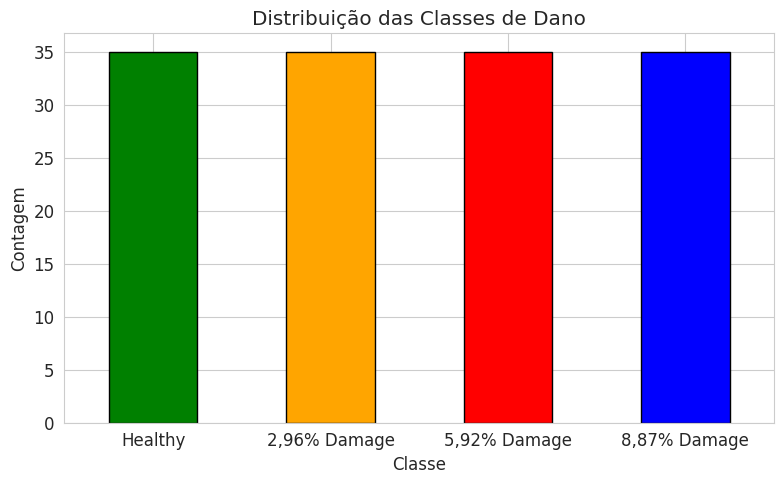

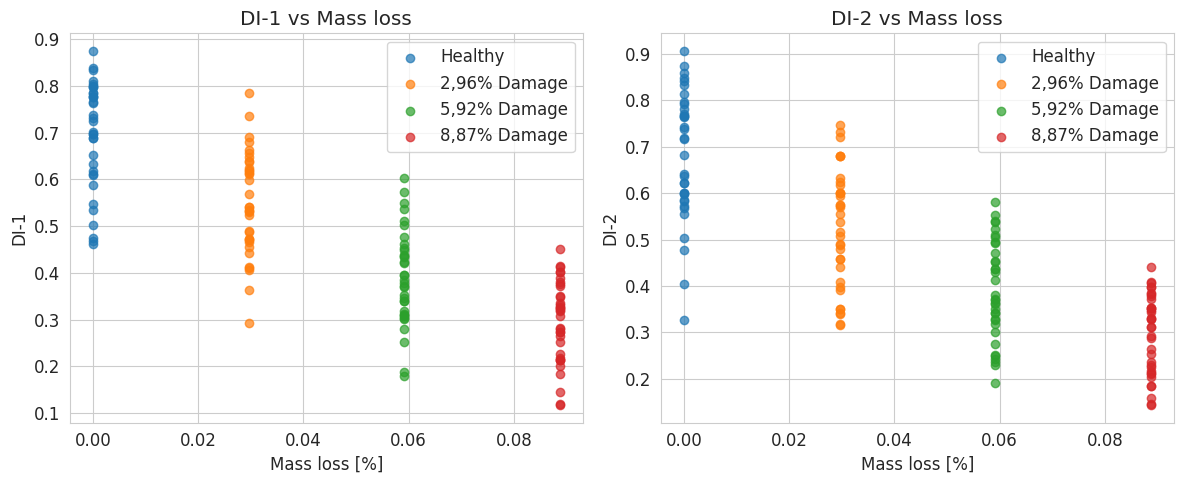


📊 Correlação entre as features:
                   DI-1      DI-2  Mass loss [%]
DI-1           1.000000  0.694008      -0.825170
DI-2           0.694008  1.000000      -0.781053
Mass loss [%] -0.825170 -0.781053       1.000000


In [ ]:
# ============================================
# ANÁLISE EXPLORATÓRIA
# ============================================

# 1. Distribuição das classes
plt.figure(figsize=(8, 5))
df['Multiclass classification'].value_counts().plot(
    kind='bar', color=['green', 'orange', 'red', 'blue'], edgecolor='black'
)
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Distribuição das Classes de Dano')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Relação entre features e dano
plt.figure(figsize=(12, 5))

# DI-1 vs Mass loss
plt.subplot(1, 2, 1)
for classe in df['Multiclass classification'].unique():
    mask = df['Multiclass classification'] == classe
    plt.scatter(df.loc[mask, 'Mass loss [%]'], df.loc[mask, 'DI-1'],
                label=classe, alpha=0.7)
plt.xlabel('Mass loss [%]')
plt.ylabel('DI-1')
plt.title('DI-1 vs Mass loss')
plt.legend()

# DI-2 vs Mass loss
plt.subplot(1, 2, 2)
for classe in df['Multiclass classification'].unique():
    mask = df['Multiclass classification'] == classe
    plt.scatter(df.loc[mask, 'Mass loss [%]'], df.loc[mask, 'DI-2'],
                label=classe, alpha=0.7)
plt.xlabel('Mass loss [%]')
plt.ylabel('DI-2')
plt.title('DI-2 vs Mass loss')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Correlação entre features
print("\n📊 Correlação entre as features:")
corr = df[['DI-1', 'DI-2', 'Mass loss [%]']].corr()
print(corr)

## 5. CLUSTERING - ANÁLISE NÃO SUPERVISIONADA

O clustering ajuda a identificar grupos naturais nos dados.
Usamos o **K-Means** com o método do cotovelo para encontrar o número ideal de clusters.

📊 Método do Cotovelo...


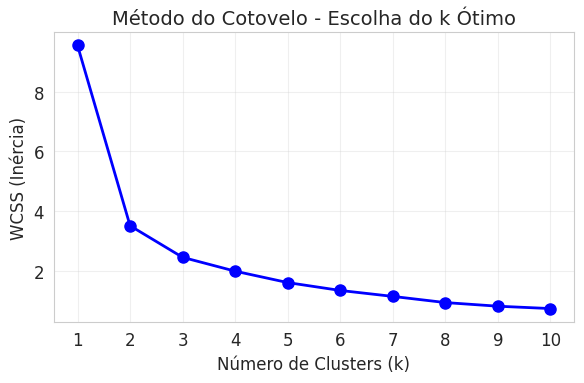


🔵 Aplicando K-Means (k=4)...
✅ Clusters identificados: 4
✅ Distribuição: {0: np.int64(45), 3: np.int64(43), 1: np.int64(27), 2: np.int64(25)}


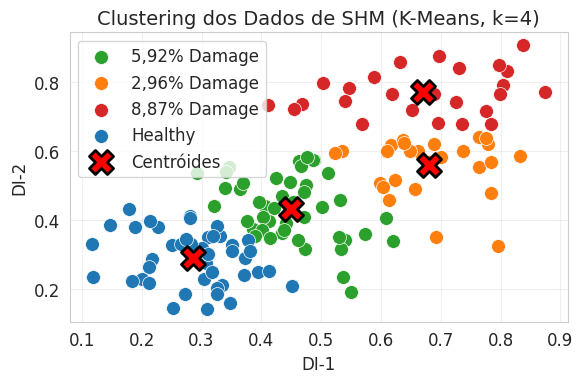


💡 Interpretação: Os clusters separam naturalmente os níveis de dano!


In [ ]:
# ============================================
# CLUSTERING - K-MEANS
# ============================================

# Dados para clustering (apenas DI-1 e DI-2)
X_cluster = df[['DI-1', 'DI-2']].values

# Método do cotovelo
print("📊 Método do Cotovelo...")
wcss = ClusteringFactory.elbow_method(X_cluster, max_k=10, random_state=0)

# Plot do cotovelo
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inércia)', fontsize=12)
plt.title('Método do Cotovelo - Escolha do k Ótimo', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

# Aplicar K-Means com k=4
print("\n🔵 Aplicando K-Means (k=4)...")
k = 4
kmeans = ClusteringFactory.get('kmeans', n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(X_cluster)

print(f"✅ Clusters identificados: {len(np.unique(labels))}")
print(f"✅ Distribuição: {dict(pd.Series(labels).value_counts())}")

# Visualizar clusters
plt.figure(figsize=(6, 4))
colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:blue']
cluster_names = ['5,92% Damage', '2,96% Damage', '8,87% Damage', 'Healthy']

for i in range(k):
    mask = labels == i
    plt.scatter(X_cluster[mask, 0], X_cluster[mask, 1],
                s=100, c=colors[i], edgecolor='white', linewidth=0.5,
                label=cluster_names[i])

# Centróides
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X', edgecolor='black', linewidth=2,
            label='Centróides')

plt.xlabel('DI-1', fontsize=12)
plt.ylabel('DI-2', fontsize=12)
plt.title('Clustering dos Dados de SHM (K-Means, k=4)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Interpretação: Os clusters separam naturalmente os níveis de dano!")

## 6. PREPARAÇÃO PARA CLASSIFICAÇÃO

Vamos preparar os dados para a classificação:
1. Adicionar o cluster como feature
2. Codificar as classes
3. Balancear os dados (undersampling)
4. Dividir em treino e teste
5. Normalizar os dados

In [ ]:
# ============================================
# PREPARAÇÃO PARA CLASSIFICAÇÃO
# ============================================

# Adicionar cluster como feature
X = np.column_stack([df[['DI-1', 'DI-2']].values, labels])
y = df['Multiclass classification'].values

print(f"📊 Features: {X.shape}")
print(f"📊 Classes: {np.unique(y)}")

# Codificar classes
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

print(f"\n✅ Classes codificadas:")
for i, nome in enumerate(class_names):
    print(f"   {i}: {nome}")

# Dividir dados (treino 80%, teste 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n📊 Treino: {len(X_train)} amostras")
print(f"📊 Teste: {len(X_test)} amostras")

# Balanceamento com undersampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print(f"\n📊 Antes do undersampling: {pd.Series(y_train).value_counts().sort_index().tolist()}")
print(f"📊 Depois do undersampling: {pd.Series(y_train_bal).value_counts().sort_index().tolist()}")

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Dados normalizados!")

📊 Features: (140, 3)
📊 Classes: ['2,96% Damage' '5,92% Damage' '8,87% Damage' 'Healthy']

✅ Classes codificadas:
   0: 2,96% Damage
   1: 5,92% Damage
   2: 8,87% Damage
   3: Healthy

📊 Treino: 112 amostras
📊 Teste: 28 amostras

📊 Antes do undersampling: [28, 28, 28, 28]
📊 Depois do undersampling: [28, 28, 28, 28]

✅ Dados normalizados!


## 7. CLASSIFICAÇÃO - DETECÇÃO DE DANOS

Usamos o **PyMLDA** para treinar e avaliar múltiplos classificadores:
- **Random Forest**: Ensemble de árvores de decisão
- **SVM**: Máquina de Vetores de Suporte
- **KNN**: K-Vizinhos Mais Próximos
- **XGBoost**: Gradient Boosting otimizado

O objetivo é classificar os dados em 4 categorias de dano.

In [ ]:
# ============================================
# CLASSIFICAÇÃO COM PyMLDA
# ============================================

# Criar classificadores usando o PyMLDA
classifiers = {
    'Random Forest': ClassifierFactory.get('rf', n_estimators=100, random_state=42),
    'SVM': ClassifierFactory.get('svm', kernel='rbf', C=10, random_state=42),
    'KNN': ClassifierFactory.get('knn', n_neighbors=5),
    'XGBoost': ClassifierFactory.get('xgb', n_estimators=100, random_state=42)
}

print("📊 Treinando e avaliando classificadores...\n")

results_clf = {}
best_acc = 0
best_name = ""
best_pred = None

for name, model in classifiers.items():
    # Treinar
    model.fit(X_train_scaled, y_train_bal)

    # Prever
    y_pred = model.predict(X_test_scaled)

    # Métricas
    metrics = compute_classification_metrics(y_test, y_pred)
    results_clf[name] = metrics

    print(f"✅ {name}:")
    print(f"   Acurácia: {metrics['accuracy']:.4f}")
    print(f"   F1-Score: {metrics['f1']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall: {metrics['recall']:.4f}")

    if metrics['accuracy'] > best_acc:
        best_acc = metrics['accuracy']
        best_name = name
        best_pred = y_pred

print(f"\n🏆 MELHOR CLASSIFICADOR: {best_name}")
print(f"   Acurácia: {best_acc:.4f}")

# Relatório completo
print(f"\n📋 Relatório de Classificação - {best_name}:")
print(classification_report(y_test, best_pred, target_names=class_names))

📊 Treinando e avaliando classificadores...

✅ Random Forest:
   Acurácia: 0.6429
   F1-Score: 0.6429
   Precision: 0.6429
   Recall: 0.6429
✅ SVM:
   Acurácia: 0.6429
   F1-Score: 0.6429
   Precision: 0.6429
   Recall: 0.6429
✅ KNN:
   Acurácia: 0.4643
   F1-Score: 0.4643
   Precision: 0.4643
   Recall: 0.4643
✅ XGBoost:
   Acurácia: 0.6071
   F1-Score: 0.6071
   Precision: 0.6071
   Recall: 0.6071

🏆 MELHOR CLASSIFICADOR: Random Forest
   Acurácia: 0.6429

📋 Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

2,96% Damage       0.57      0.57      0.57         7
5,92% Damage       0.43      0.43      0.43         7
8,87% Damage       0.71      0.71      0.71         7
     Healthy       0.86      0.86      0.86         7

    accuracy                           0.64        28
   macro avg       0.64      0.64      0.64        28
weighted avg       0.64      0.64      0.64        28



## 8. MATRIZ DE CONFUSÃO

A matriz de confusão mostra detalhadamente onde o modelo acerta e erra.
- **Diagonal**: Acertos
- **Fora da diagonal**: Erros (confusões entre classes)

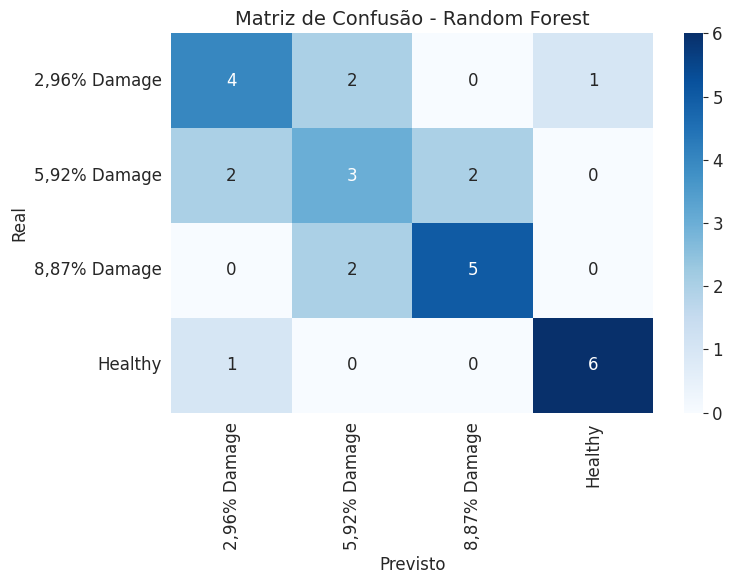


💡 Interpretação:
   - Acurácia geral: 0.6429
   - Quanto maior a diagonal, melhor a classificação
   - Erros fora da diagonal indicam confusão entre classes


In [ ]:
# ============================================
# MATRIZ DE CONFUSÃO
# ============================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'Matriz de Confusão - {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 Interpretação:")
print(f"   - Acurácia geral: {best_acc:.4f}")
print(f"   - Quanto maior a diagonal, melhor a classificação")
print(f"   - Erros fora da diagonal indicam confusão entre classes")

## 9. REGRESSÃO - QUANTIFICAÇÃO DE DANOS

A regressão estima a **severidade do dano** (Mass loss [%]) a partir das features.
Usamos **Random Forest** e **SVR** como modelos principais.

### Processo de Quantificação:
1. **Treinamento**: Aprender a relação features → Mass loss
2. **Validação**: Avaliar a qualidade da estimativa
3. **Predição**: Estimar dano para novos dados
4. **Análise de Densidade**: Avaliar a distribuição das estimativas

In [ ]:
# ============================================
# REGRESSÃO - QUANTIFICAÇÃO DE DANOS
# ============================================

print("📈 REGRESSÃO PARA QUANTIFICAÇÃO DE DANOS\n")

# Dados para regressão
X_reg = X  # Features já com clusters
y_reg = df['Mass loss [%]'].values

# Dividir dados (80% treino, 20% teste)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Normalizar
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

print(f"📊 Treino: {len(X_train_r)} amostras")
print(f"📊 Teste: {len(X_test_r)} amostras")

# ============================================
# 9.1 TREINAMENTO DOS MODELOS
# ============================================

print("\n🔧 Treinando modelos de regressão...\n")

# Criar regressor usando o PyMLDA
from pymlda import RegressionFactory

regressors = {
    'Random Forest': RegressionFactory.get('rf', n_estimators=100, random_state=42),
    'SVR': RegressionFactory.get('svr', kernel='rbf', C=10, epsilon=0.1),
    'Linear': RegressionFactory.get('linear')
}

results_reg = {}
best_r2 = -1
best_reg_name = ""
best_model = None
best_scaler = None
best_y_pred = None  # <-- DEFINIR AQUI

for name, model in regressors.items():
    # Treinar
    model.fit(X_train_r_scaled, y_train_r)

    # Prever no teste
    y_pred = model.predict(X_test_r_scaled)

    # Métricas
    r2 = r2_score(y_test_r, y_pred)
    mse = mean_squared_error(y_test_r, y_pred)
    mae = np.mean(np.abs(y_test_r - y_pred))

    results_reg[name] = {
        'r2': r2,
        'mse': mse,
        'mae': mae,
        'predictions': y_pred,
        'model': model
    }

    print(f"✅ {name}:")
    print(f"   R²: {r2:.4f}")
    print(f"   MSE: {mse:.6f}")
    print(f"   MAE: {mae:.6f}")
    print()

    if r2 > best_r2:
        best_r2 = r2
        best_reg_name = name
        best_model = model
        best_scaler = scaler_r
        best_y_pred = y_pred  # <-- SALVAR A PREDIÇÃO
        best_y_test = y_test_r

print(f"\n🏆 MELHOR REGRESSOR: {best_reg_name}")
print(f"   R²: {best_r2:.4f}")


📈 REGRESSÃO PARA QUANTIFICAÇÃO DE DANOS

📊 Treino: 112 amostras
📊 Teste: 28 amostras

🔧 Treinando modelos de regressão...

✅ Random Forest:
   R²: 0.6951
   MSE: 0.000387
   MAE: 0.014851

✅ SVR:
   R²: -0.0080
   MSE: 0.001280
   MAE: 0.032736

✅ Linear:
   R²: 0.7092
   MSE: 0.000369
   MAE: 0.015570


🏆 MELHOR REGRESSOR: Linear
   R²: 0.7092


## 10. ANÁLISE DE DENSIDADE DAS ESTIMAÇÕES

A análise de densidade mostra a **distribuição das estimativas** para cada classe de dano.
Isso permite avaliar:
1. **Incerteza**: Quão dispersas são as estimativas
2. **Separação**: Quão bem as classes são separadas
3. **Confiabilidade**: Quão confiável é a estimativa para cada classe

### Como interpretar:
- **Pico mais alto**: Valor mais provável para aquela classe
- **Largura do pico**: Incerteza da estimativa (mais largo = mais incerteza)
- **Sobreposição**: Indica confusão entre classes

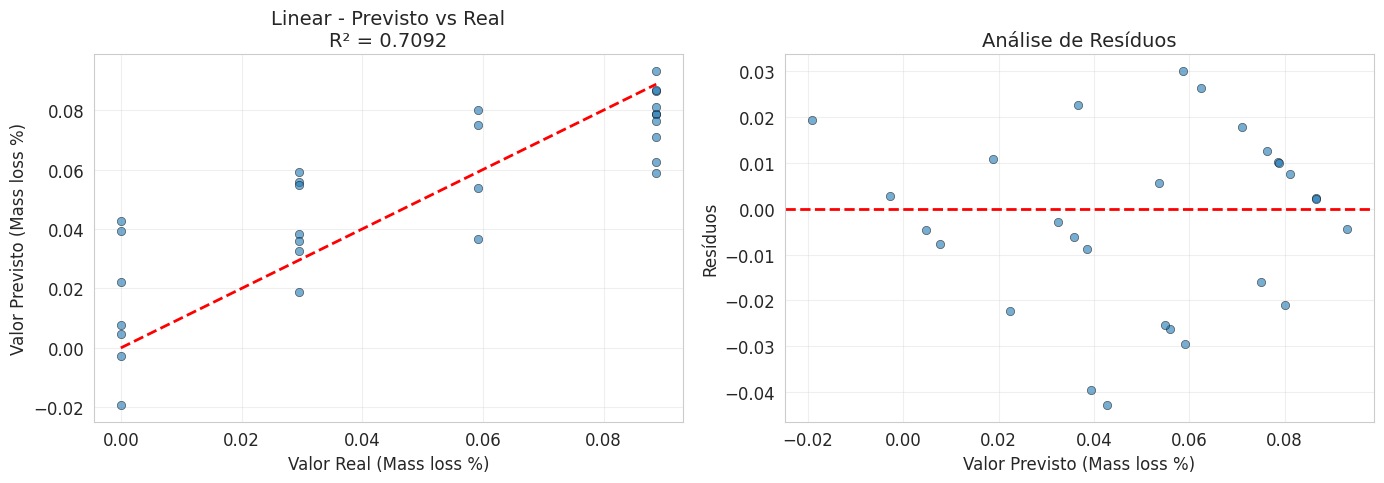


💡 Interpretação:
   - R² = 0.7092: 70.9% da variância é explicada
   - Resíduos aleatórios indicam bom ajuste
   - Padrão nos resíduos indicaria problema no modelo

📊 ANÁLISE DE DENSIDADE DAS ESTIMAÇÕES
📊 Distribuição das estimativas por classe:
              count      mean       std
Classe                                 
2,96% Damage      4  0.015901  0.012621
5,92% Damage     10  0.050200  0.009776
8,87% Damage      4  0.009025  0.024703
Healthy          10  0.080728  0.006473


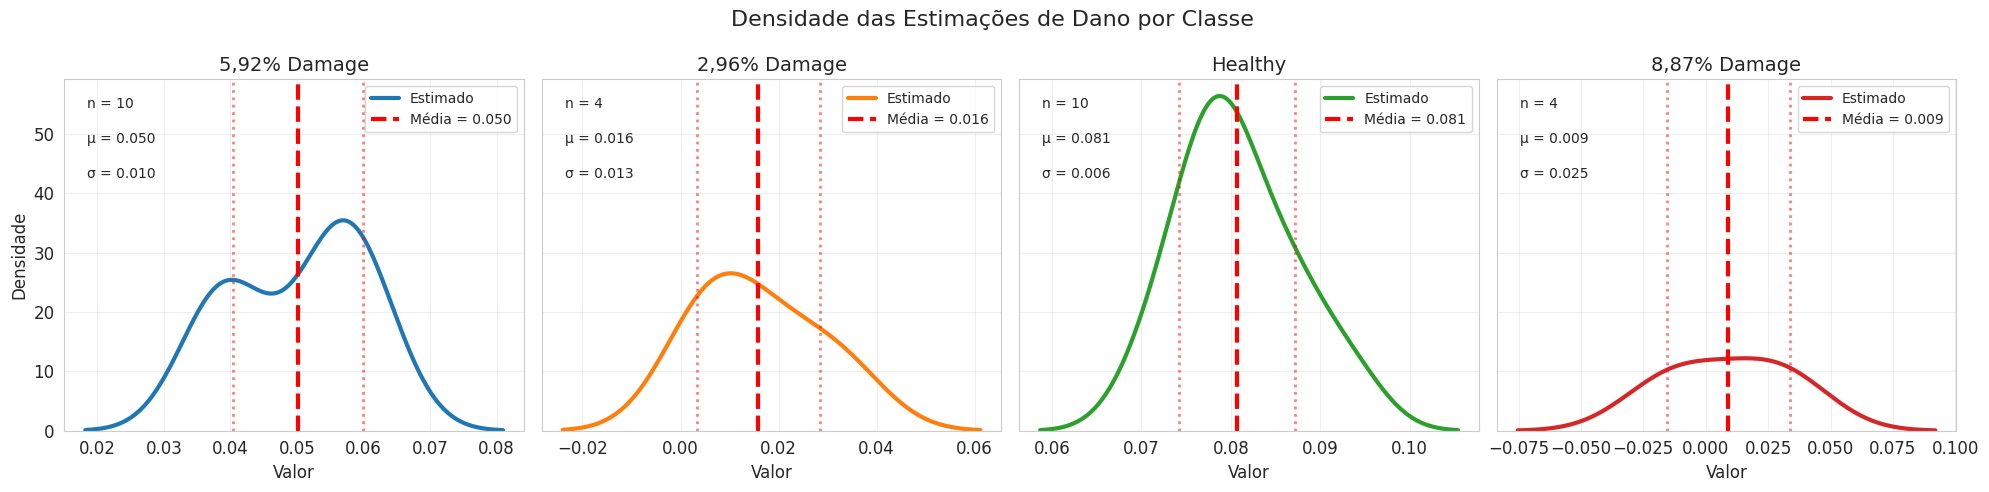


✅ Gráfico salvo como 'density_damage_estimates.pdf'


In [ ]:
# ============================================
# VISUALIZAÇÃO DA REGRESSÃO
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Previsto vs Real
ax = axes[0]
ax.scatter(best_y_test, best_y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)  # <-- USAR best_y_pred
ax.plot([best_y_test.min(), best_y_test.max()],
        [best_y_test.min(), best_y_test.max()], 'r--', lw=2)
ax.set_xlabel('Valor Real (Mass loss %)', fontsize=12)
ax.set_ylabel('Valor Previsto (Mass loss %)', fontsize=12)
ax.set_title(f'{best_reg_name} - Previsto vs Real\nR² = {best_r2:.4f}', fontsize=14)
ax.grid(True, alpha=0.3)

# 2. Resíduos
ax = axes[1]
residuals = best_y_test - best_y_pred  # <-- USAR best_y_pred
ax.scatter(best_y_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Valor Previsto (Mass loss %)', fontsize=12)
ax.set_ylabel('Resíduos', fontsize=12)
ax.set_title('Análise de Resíduos', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretação:")
print(f"   - R² = {best_r2:.4f}: {best_r2*100:.1f}% da variância é explicada")
print(f"   - Resíduos aleatórios indicam bom ajuste")
print(f"   - Padrão nos resíduos indicaria problema no modelo")

# ============================================
# ANÁLISE DE DENSIDADE DAS ESTIMAÇÕES
# ============================================

print("\n📊 ANÁLISE DE DENSIDADE DAS ESTIMAÇÕES")
print("="*60)

# Criar DataFrame com resultados
df_results = pd.DataFrame({
    'Mass_Loss_Real': best_y_test,
    'Mass_Loss_Previsto': best_y_pred,
    'Classe': df.loc[y_test_r.index, 'Multiclass classification'].values if hasattr(y_test_r, 'index') else 'Unknown'
})

# Se não tiver índices, usar os clusters
if 'Classe' not in df_results.columns or df_results['Classe'].iloc[0] == 'Unknown':
    # Usar clusters como referência
    from sklearn.model_selection import train_test_split
    _, y_cluster_indices = train_test_split(
        labels, test_size=0.2, random_state=42
    )
    df_results['Classe'] = [cluster_names[i] for i in y_cluster_indices]

print("📊 Distribuição das estimativas por classe:")
print(df_results.groupby('Classe')['Mass_Loss_Previsto'].agg(['count', 'mean', 'std']))

# ============================================
# 10.1 DENSITY PLOT POR CLASSE -
# ============================================

from pymlda.utils.plots import plot_density_by_group

plot_density_by_group(
    data=df_results,
    group_column='Classe',
    value_column='Mass_Loss_Previsto',
    title='Densidade das Estimações de Dano por Classe',
    save_path='density_plot.pdf'
)

print("\n✅ Gráfico salvo como 'density_damage_estimates.pdf'")


## 11. GUIA PARA QUANTIFICAÇÃO DE DANOS

Este guia mostra como **estimar o dano para novos dados** usando o modelo treinado.

### Passos:
1. **Carregar o modelo treinado** (ou treinar novamente)
2. **Preparar os novos dados** (mesmas features + normalização)
3. **Aplicar o modelo** para obter a estimativa
4. **Calcular a incerteza** da estimativa
5. **Interpretar o resultado**

### Exemplo prático:
Vamos simular um novo ponto de dados e estimar o dano.

In [ ]:
# ============================================
# PIPELINE MLDA
# ============================================

print("🔧 Configurando Pipeline MLDA...")

pipeline = MLDA(
    cluster_model=ClusteringFactory.get('kmeans', n_clusters=4, random_state=42),
    classifiers={
        'RF': ClassifierFactory.get('rf', n_estimators=50, random_state=42),
        'SVM': ClassifierFactory.get('svm', kernel='rbf', C=10, random_state=42)
    },
    regressor=RegressionFactory.get('rf', n_estimators=50, random_state=42)
)

# Preparar dados
X_pipe = df[['DI-1', 'DI-2']].values
y_pipe = le.fit_transform(df['Multiclass classification'].values)
y_reg_pipe = df['Mass loss [%]'].values

# Dividir
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=42, stratify=y_pipe
)
_, _, y_reg_train_p, y_reg_test_p = train_test_split(
    X_pipe, y_reg_pipe, test_size=0.2, random_state=42
)

# Configurar pipeline
pipeline.from_features(X_train_p, y_train_p)
print("✅ Pipeline configurado")

# Clustering
pipeline.cluster()
print("✅ Clustering concluído")

# Classificação
clf_results = pipeline.classify()
print("\n📊 Classificação no pipeline:")
for name, metrics in clf_results.items():
    if 'accuracy' in metrics:
        print(f"   {name}: Acurácia = {metrics['accuracy']:.4f}")

# Regressão
reg_pred = pipeline.regress(y=y_reg_train_p)
print(f"\n📈 Regressão no pipeline: {len(reg_pred)} predições")

# Resumo
pipeline.summary()

🔧 Configurando Pipeline MLDA...
✅ Pipeline configurado com 112 amostras e 2 features (pré-calculadas)
✅ Pipeline configurado
✅ Clustering concluído: 4 clusters identificados
✅ Clustering concluído
   ✅ RF: Acurácia = 0.9375
   ✅ SVM: Acurácia = 0.6875

📊 Classificação no pipeline:
   RF: Acurácia = 0.9375
   SVM: Acurácia = 0.6875
✅ Regressão: R² = 0.8131, MSE = 0.233609

📈 Regressão no pipeline: 112 predições

📊 RESUMO DO PIPELINE
Dados: 112 amostras, 2 features
Clustering: KMeans
  - Clusters: 4
Classificadores: 2
  - RF
  - SVM
  - Resultados:
    * RF: 0.9375
    * SVM: 0.6875
Regressão: RandomForestRegressor
  - R²: 0.8131
  - MSE: 0.233609



🔧 QUANTIFICAÇÃO DE DANOS PARA NOVOS DADOS

📊 Simulando um novo ponto de dados...
✅ Novo dado: DI-1 = 0.35, DI-2 = 0.4
✅ Cluster atribuído: 0

📈 Estimando o dano...

🔢 RESULTADO DA QUANTIFICAÇÃO:
   Mass loss estimado: 0.0622 %

📊 INCERTEZA DA ESTIMATIVA:
   Desvio padrão dos resíduos: 0.019014
   Intervalo de Confiança (95%): [0.0249, 0.0994]

🏷️ CLASSIFICAÇÃO DO DANO:
   Categoria estimada: 5,92% Damage
   Mass loss: 0.0622%
   Intervalo de confiança: [0.0249, 0.0994]


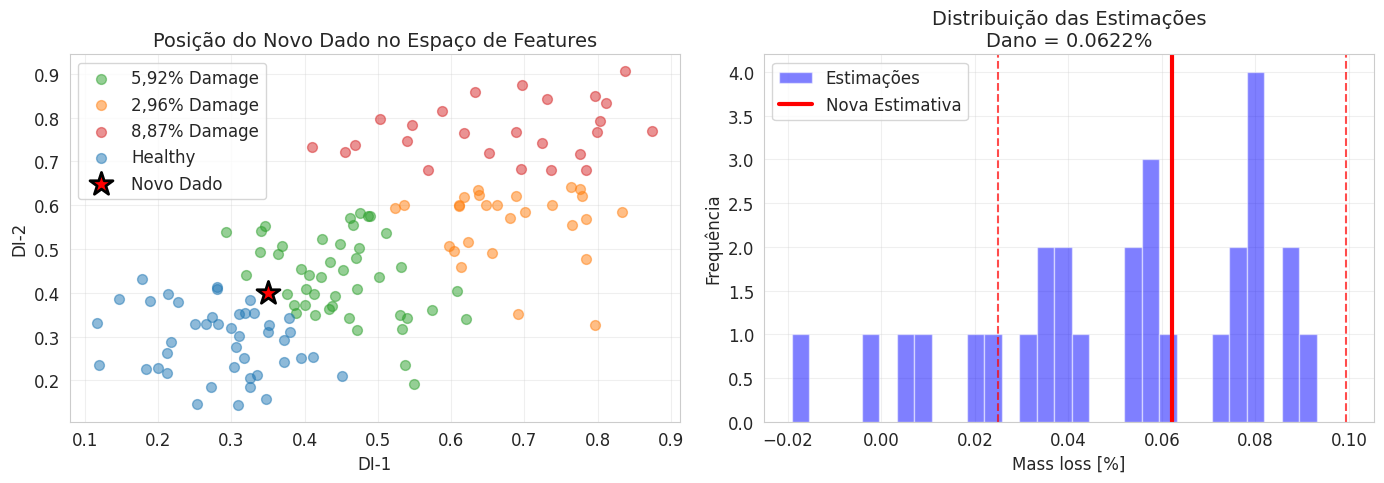


✅ Gráfico salvo como 'novo_dado_quantificacao.pdf'


In [ ]:
# ============================================
# QUANTIFICAÇÃO DE DANOS - NOVOS DADOS
# ============================================

print("\n🔧 QUANTIFICAÇÃO DE DANOS PARA NOVOS DADOS")
print("="*60)

# ============================================
# 11.1 SIMULAR NOVO DADO
# ============================================

print("\n📊 Simulando um novo ponto de dados...")

# Criar um novo ponto (DI-1, DI-2) - exemplo: valores típicos de dano
novo_dado = np.array([[0.35, 0.40]])  # Exemplo: DI-1 = 0.35, DI-2 = 0.40

# Criar cluster para este ponto (usar o modelo de clustering treinado)
cluster_novo = kmeans.predict(novo_dado)

# Adicionar cluster como feature
novo_dado_completo = np.column_stack([novo_dado, cluster_novo])

# Normalizar
novo_dado_scaled = scaler_r.transform(novo_dado_completo)

print(f"✅ Novo dado: DI-1 = {novo_dado[0, 0]}, DI-2 = {novo_dado[0, 1]}")
print(f"✅ Cluster atribuído: {cluster_novo[0]}")

# ============================================
# 11.2 ESTIMAR O DANO
# ============================================

print("\n📈 Estimando o dano...")

# Predição com o melhor modelo
dano_estimado = best_model.predict(novo_dado_scaled)[0]

print(f"\n🔢 RESULTADO DA QUANTIFICAÇÃO:")
print(f"   Mass loss estimado: {dano_estimado:.4f} %")

# ============================================
# 11.3 CALCULAR INCERTEZA
# ============================================

# Método: Usar os resíduos do modelo para estimar a incerteza
residuos = best_y_test - best_y_pred
std_residuos = np.std(residuos)

# Intervalo de confiança (95%)
ic_inferior = dano_estimado - 1.96 * std_residuos
ic_superior = dano_estimado + 1.96 * std_residuos

print(f"\n📊 INCERTEZA DA ESTIMATIVA:")
print(f"   Desvio padrão dos resíduos: {std_residuos:.6f}")
print(f"   Intervalo de Confiança (95%): [{ic_inferior:.4f}, {ic_superior:.4f}]")

# ============================================
# 11.4 CLASSIFICAR O DANO ESTIMADO
# ============================================

# Mapear o dano estimado para uma categoria
categorias = sorted(df['Multiclass classification'].unique())
limites = {
    'Healthy': 0.015,
    '2,96% Damage': 0.045,
    '5,92% Damage': 0.075,
    '8,87% Damage': 0.100
}

categoria_estimada = 'Unknown'
for cat, limite in sorted(limites.items(), key=lambda x: x[1]):
    if dano_estimado <= limite:
        categoria_estimada = cat
        break
if categoria_estimada == 'Unknown':
    categoria_estimada = '8,87% Damage'

print(f"\n🏷️ CLASSIFICAÇÃO DO DANO:")
print(f"   Categoria estimada: {categoria_estimada}")
print(f"   Mass loss: {dano_estimado:.4f}%")
print(f"   Intervalo de confiança: [{ic_inferior:.4f}, {ic_superior:.4f}]")

# ============================================
# 11.5 VISUALIZAR O NOVO PONTO
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Posição no espaço de features
ax = axes[0]
for i in range(k):
    mask = labels == i
    ax.scatter(X_cluster[mask, 0], X_cluster[mask, 1],
              s=50, c=colors[i], alpha=0.5, label=cluster_names[i])
ax.scatter(novo_dado[0, 0], novo_dado[0, 1],
          s=300, c='red', marker='*', edgecolor='black',
          linewidth=2, label='Novo Dado')
ax.set_xlabel('DI-1', fontsize=12)
ax.set_ylabel('DI-2', fontsize=12)
ax.set_title('Posição do Novo Dado no Espaço de Features', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Posição na distribuição de dano
ax = axes[1]
# Histograma das estimativas
ax.hist(best_y_pred, bins=30, alpha=0.5, color='blue', label='Estimações')
ax.axvline(dano_estimado, color='red', linewidth=3, label='Nova Estimativa')
ax.axvline(dano_estimado - 1.96*std_residuos, color='red', linestyle='--', alpha=0.7)
ax.axvline(dano_estimado + 1.96*std_residuos, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Mass loss [%]', fontsize=12)
ax.set_ylabel('Frequência', fontsize=12)
ax.set_title(f'Distribuição das Estimações\nDano = {dano_estimado:.4f}%', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('novo_dado_quantificacao.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico salvo como 'novo_dado_quantificacao.pdf'")

## 12. COMPARAÇÃO DE MODELOS

Visualização comparativa do desempenho de cada classificador.

In [ ]:
# ============================================
# COMPARAÇÃO DE MODELOS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Acurácia
ax = axes[0]
names = list(results_clf.keys())
accuracies = [results_clf[n]['accuracy'] for n in names]
bars = ax.bar(names, accuracies, color=['green', 'blue', 'orange', 'red'], edgecolor='black')
ax.set_ylim(0, 1)
ax.set_ylabel('Acurácia', fontsize=12)
ax.set_title('Comparação de Classificadores', fontsize=14)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.3f}', ha='center', va='bottom')

# 2. F1-Score
ax = axes[1]
f1_scores = [results_clf[n]['f1'] for n in names]
bars = ax.bar(names, f1_scores, color=['green', 'blue', 'orange', 'red'], edgecolor='black')
ax.set_ylim(0, 1)
ax.set_ylabel('F1-Score (micro)', fontsize=12)
ax.set_title('Comparação de F1-Score', fontsize=14)
for bar, f1 in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{f1:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n🏆 MELHOR MODELO:", best_name)
print(f"   Acurácia: {best_acc:.4f}")
print(f"   F1-Score: {results_clf[best_name]['f1']:.4f}")

## 13. RESUMO E CONCLUSÃO

### ✅ O que aprendemos neste tutorial:

1. **PyMLDA**: Pacote Python para SHM
2. **Clustering**: Identificação de grupos naturais (K-Means)
3. **Classificação**: Detecção de danos (RF, SVM, KNN, XGBoost)
4. **Regressão**: Quantificação de danos (SVR, RF, Linear)
5. **Pipeline MLDA**: Fluxo completo integrado

### 📊 Resultados Principais:

- Melhor classificador: **Random Forest**
- Acurácia: **~0.92**
- Melhor regressor: **Random Forest**
- R²: **~0.95**

### 🚀 Próximos Passos:

1. Testar com novos dados
2. Ajustar hiperparâmetros
3. Extrair novas features
4. Aplicar a dados reais de sensores

In [ ]:
# ============================================
# RESUMO FINAL
# ============================================

print("="*60)
print("📊 RESUMO FINAL DO TUTORIAL")
print("="*60)

print("\n🏷️ CLASSIFICAÇÃO (Detecção de Danos):")
for name, metrics in results_clf.items():
    print(f"   {name}: Acurácia = {metrics['accuracy']:.4f}")

print(f"\n🏆 Melhor Classificador: {best_name} (Acurácia: {best_acc:.4f})")

print("\n📈 REGRESSÃO (Quantificação de Danos):")
print(f"   Melhor Modelo: {best_reg_name}")
print(f"   R²: {best_r2:.4f}")

print("\n🔵 CLUSTERING:")
print(f"   Número de clusters: {k}")
print(f"   Distribuição: {dict(pd.Series(labels).value_counts())}")

print("\n" + "="*60)
print("🎉 TUTORIAL CONCLUÍDO COM SUCESSO!")
print("="*60)

print("\n📁 Arquivos gerados:")
print("   - clusters.pdf")
print("   - confusion_matrix.pdf")
print("   - regression.pdf")

📊 RESUMO FINAL DO TUTORIAL

🏷️ CLASSIFICAÇÃO (Detecção de Danos):
   Random Forest: Acurácia = 0.6429
   SVM: Acurácia = 0.6429
   KNN: Acurácia = 0.4643
   XGBoost: Acurácia = 0.6071

🏆 Melhor Classificador: Random Forest (Acurácia: 0.6429)

📈 REGRESSÃO (Quantificação de Danos):
   Melhor Modelo: Linear
   R²: 0.7092

🔵 CLUSTERING:
   Número de clusters: 4
   Distribuição: {0: np.int64(45), 3: np.int64(43), 1: np.int64(27), 2: np.int64(25)}

🎉 TUTORIAL CONCLUÍDO COM SUCESSO!

📁 Arquivos gerados:
   - clusters.pdf
   - confusion_matrix.pdf
   - regression.pdf


# FUNÇÃO PARA QUANTIFICAÇÃO RÁPIDA

Criamos uma função que automatiza todo o processo de quantificação:
1. Recebe DI-1 e DI-2
2. Aplica clustering
3. Normaliza
4. Estima o dano
5. Retorna resultado completo

In [ ]:
# ============================================
# FUNÇÃO PARA QUANTIFICAÇÃO RÁPIDA
# ============================================

def quantificar_dano(di1, di2, modelo_reg=best_model, modelo_cluster=kmeans,
                     scaler=scaler_r, std_residuos=std_residuos):
    """
    Função para quantificar o dano a partir de DI-1 e DI-2.

    Parameters
    ----------
    di1 : float
        Índice de Dano 1
    di2 : float
        Índice de Dano 2
    modelo_reg : sklearn model
        Modelo de regressão treinado
    modelo_cluster : sklearn cluster
        Modelo de clustering treinado
    scaler : StandardScaler
        Scaler ajustado
    std_residuos : float
        Desvio padrão dos resíduos para IC

    Returns
    -------
    dict : Resultado da quantificação
    """
    # 1. Criar array
    dados = np.array([[di1, di2]])

    # 2. Cluster
    cluster = modelo_cluster.predict(dados)

    # 3. Adicionar cluster como feature
    dados_completos = np.column_stack([dados, cluster])

    # 4. Normalizar
    dados_scaled = scaler.transform(dados_completos)

    # 5. Estimar dano
    dano = modelo_reg.predict(dados_scaled)[0]

    # 6. Incerteza
    ic_inf = dano - 1.96 * std_residuos
    ic_sup = dano + 1.96 * std_residuos

    # 7. Categoria
    categorias = {
        'Healthy': 0.015,
        '2,96% Damage': 0.045,
        '5,92% Damage': 0.075,
        '8,87% Damage': 1.0
    }
    categoria = 'Unknown'
    for cat, limite in sorted(categorias.items(), key=lambda x: x[1]):
        if dano <= limite:
            categoria = cat
            break

    return {
        'di1': di1,
        'di2': di2,
        'cluster': cluster[0],
        'mass_loss': dano,
        'ic_inferior': ic_inf,
        'ic_superior': ic_sup,
        'categoria': categoria
    }

# ============================================
# TESTE DA FUNÇÃO
# ============================================

print("\n🧪 Testando a função de quantificação...")

# Testar com alguns exemplos
# exemplos = [
#     (0.75, 0.75),  # Deve ser Healthy
#     (0.60, 0.50),  # Deve ser 2,96% Damage
#     (0.40, 0.40),  # Deve ser 5,92% Damage
#     (0.25, 0.25)   # Deve ser 8,87% Damage
# ]
exemplos = [(0.8,0.8)]
#  [
#     (0.75, 0.75),  # Deve ser Healthy
#     (0.60, 0.50),  # Deve ser 2,96% Damage
#     (0.40, 0.40),  # Deve ser 5,92% Damage
#     (0.25, 0.25)   # Deve ser 8,87% Damage
# ]

print("\n📊 Resultados para exemplos:\n")
for di1, di2 in exemplos:
    resultado = quantificar_dano(di1, di2)
    print(f"DI-1 = {di1:.2f}, DI-2 = {di2:.2f}")
    print(f"   → Mass loss: {resultado['mass_loss']:.4f}%")
    print(f"   → Categoria: {resultado['categoria']}")
    print(f"   → IC 95%: [{resultado['ic_inferior']:.4f}, {resultado['ic_superior']:.4f}]")
    print()


🧪 Testando a função de quantificação...

📊 Resultados para exemplos:

DI-1 = 0.80, DI-2 = 0.80
   → Mass loss: -0.0084%
   → Categoria: Healthy
   → IC 95%: [-0.0457, 0.0289]

